In [39]:
#importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [11]:
df = pd.read_csv(r"C:\Users\rapha\Downloads\income.csv")
df

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


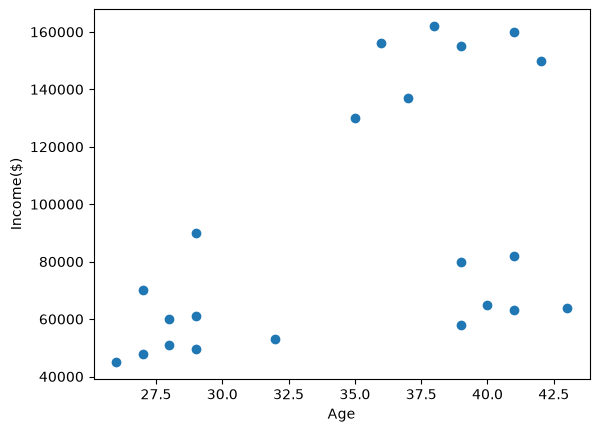

In [19]:
#plot the dataframe for visualization
plt.scatter(df["Age"], df["Income($)"])
plt.xlabel("Age")
plt.ylabel("Income($)")
plt.show()

In [29]:
#drop  the name column before scaling
x = df.drop("Name" ,axis = 1)
scaler = StandardScaler()
scaler.fit(x)
df_scaled = scaler.transform(x)
print(df_scaled)


[[-1.35605536 -0.48068427]
 [-1.00915747 -0.01015907]
 [-1.00915747 -0.69242061]
 [-1.18260641 -0.71594687]
 [ 1.24567876  1.40141653]
 [ 0.72533193  1.51904783]
 [ 1.07222982  1.63667914]
 [ 0.55188299  1.68373166]
 [ 0.20498511  1.54257409]
 [ 0.03153617  0.93089133]
 [ 0.37843405  1.09557515]
 [-1.5295043  -1.06884077]
 [-1.35605536 -0.99826199]
 [-1.18260641 -0.92768321]
 [-1.00915747 -0.9629726 ]
 [-0.48881065 -0.88063069]
 [ 0.89878087 -0.59831557]
 [ 1.07222982 -0.64536809]
 [ 1.4191277  -0.62184183]
 [ 0.72533193 -0.24542167]
 [ 1.07222982 -0.19836915]
 [ 0.72533193 -0.76299939]]


In [40]:
model  =  KMeans(n_clusters = 3)
model.fit(df_scaled)
predictions = model.predict(df_scaled)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [45]:
#model evaluation silhoutte score
s_score = silhouette_score(df_scaled,predictions)
print(f"The silhouette score is {s_score}")


The silhouette score is 0.7119890290065082


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

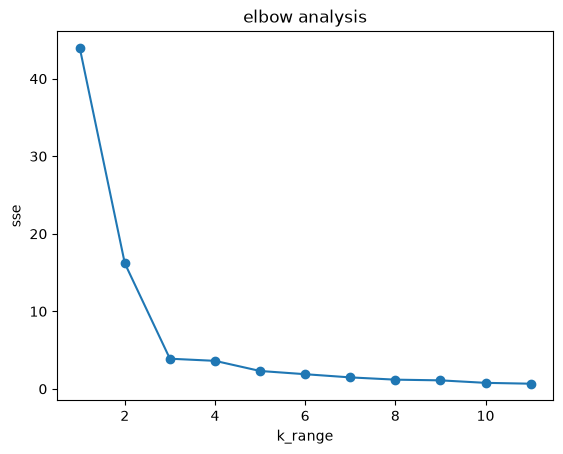

In [48]:
#model evaluation finding the optimal k
sse = []
k_range = range(1,12)
for k in k_range:
    kms= KMeans(n_clusters = k)
    kms.fit(df_scaled)
    sse.append(kms.inertia_) 
    #visualize
plt.plot(k_range,sse, marker = "o")
plt.xlabel("k_range")
plt.ylabel("sse")
plt.title("elbow analysis")
plt.show()
    


In [ ]:
#visualize our output

In [49]:
predictions

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [55]:
df_scaled = pd.DataFrame(df_scaled , columns = ['age','income'])
df_scaled["cluster"] = predictions
df_scaled


,age,income,cluster
0,-1.356055,-0.480684,1
1,-1.009157,-0.010159,1
2,-1.009157,-0.692421,1
3,-1.182606,-0.715947,1
4,1.245679,1.401417,2
5,0.725332,1.519048,2
6,1.072230,1.636679,2
7,0.551883,1.683732,2
8,0.204985,1.542574,2
9,0.031536,0.930891,2


In [56]:
df0 = df_scaled[df_

KeyError: 'Age'